[![Open In Collab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AIPI-590-XAI/Duke-AI-XAI/blob/main/assignments/xai_decathlon.ipynb)

## Core Lesson

Different explanation methods answer different kinds of questions.

Your job is to find out where your assigned method is useful, where it is only partially useful, and where it simply does not fit the task. A method can earn a strong score for saying something clear and justified, including: "this method cannot answer this event question."

This notebook is intentionally only the individual round. Later, you may compare results with classmates who used different methods.


## Scoring Rules

For each event, assign your method one medal:

- **Gold:** directly answers the event question with convincing evidence.
- **Silver:** gives useful partial evidence, but another method or assumption is needed.
- **Bronze:** gives weak, indirect, or fragile evidence.
- **DNF:** does not finish: the method is mismatched, misleading, or not usable for the event.

A pretty visualization is not automatically a medal. Score the method based on whether it answers the event question.


## The Ten Events

| Event | Question |
|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? |
| 5. Compare Two Predictions | Why were two cases classified differently? |
| 6. Feature Interactions | Which tabular variables work together? |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? |
| 8. Explain a Failure | Why did the model make this mistake? |
| 9. Estimate Trustworthiness | Should a human trust this prediction? |
| 10. Reverse Engineer Strategy | What strategy has each model learned? |

## Results Table

Merged from the three individual LIME notebooks (Oge: Events 1–3, Jaideep: Events 4–6, Kedar: Events 7–10).

**Assigned method:** LIME  
**Team:** Oge · Jaideep Aher · Kedar

| Event | Question | Medal | Evidence from my method | Limitations or notes | Owner |
|---|---|---|---|---|---|
| 1. Most Important Feature | What variable most strongly influences the tabular model's predictions? | Silver | Across 24 probe rows, `zip_proxy` had the largest mean abs LIME weight (0.135), then `debt_ratio` (0.119) and `recent_late_payments` (0.062). | Aggregating local LIME is only an approximate global ranking; `zip_proxy` may be a proxy, not a causal risk driver. | Oge |
| 2. One Specific Prediction | Why did this individual tabular prediction occur? | Gold | For `tabular_local_case` (idx=718, true=0, P(high)≈0.50), LIME credits `zip_proxy` and `debt_ratio` bins as the strongest local drivers of the near-boundary prediction (local R²≈0.33). | Explains this row only; moderate local fidelity means the surrogate is imperfect. | Oge |
| 3. Dataset Bias or Shortcut | Is the image model relying on a spurious shortcut? | Gold | `shortcut_probe` (circle+marker) → square at P=0.98; `contrast_square` (square, no marker) → P(square)=0.07. LIME region maps credit the red corner more than shape. | Diagnose shortcut via probe cases + local maps; not a causal audit of the full dataset. | Oge |
| 4. Global Feature Effect | As one tabular feature changes, what happens to predictions? | Silver | Kept 8 test rows and only changed `debt_ratio`. Mean P(high risk) went from 0.137 to 0.404, and the average LIME weight for debt went from about -0.10 to about +0.19. | LIME is local. Averaging those weights is not a PDP or ALE curve, and the local R² was weak in the middle of the grid. | Jaideep |
| 5. Compare Two Predictions | Why were two cases classified differently? | Silver | Low case P(high risk)=0.022 and high case=0.789. Biggest LIME gaps: `debt_ratio`, `zip_proxy`, and `recent_late_payments`. | Explains these two rows only. Low-risk fit was weak (R²=0.388). | Jaideep |
| 6. Feature Interactions | Which tabular variables work together? | DNF | At high debt, mean LIME weight for `debt_ratio` was 0.192 at age 25 and 0.193 at age 45 — no age×debt interaction seen. | Default LIME is additive with no interaction term; need SHAP interactions or a two-way PDP. | Jaideep |
| 7. Where Is the Model Looking? | What region of an image drives the prediction? | Gold | LimeImageExplainer highlights superpixels that locally support the predicted class on assigned image cases (reference/contrast/shortcut). | Segmentation choice and sampling noise can shift boundaries; LIME is local/approximate, not a gradient heatmap. | Kedar |
| 8. Explain a Failure | Why did the model make this mistake? | Gold | LIME attributes local evidence for wrong predictions: image failure region maps (often marker/shortcut) and tabular failure feature weights toward the incorrect class. | Explains this instance, not a global failure mode. | Kedar |
| 9. Estimate Trustworthiness | Should a human trust this prediction? | Silver | Confidence + LIME fidelity/sanity: shortcut_probe is high-confidence but marker-driven (do not trust); tabular high_case looks more sensible when top features align with risk factors. | LIME cannot certify trust alone (no calibration/OOD/robustness). | Kedar |
| 10. Reverse Engineer Strategy | What strategy has each model learned? | Silver | Aggregated tabular LIME ranks debt/late-payment (+ proxy-like) features; image LIME shows predictions track the red marker more than shape. | Strategy inferred from many local surrogates, not true global attribution. | Kedar |


In [1]:
#@title Setup
# Run this cell first. It imports only the libraries needed to create the target models.
# You may add your own XAI imports later in the "Your method implementation" section.

import math
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (7, 4)
plt.rcParams["axes.grid"] = True

SEED = 42
rng = np.random.default_rng(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", DEVICE)

Device: cpu


In [2]:
#@title Event guide helper
# This table points you to the model/data objects for each event.

EVENTS = [
    "1. Most important feature",
    "2. One specific prediction",
    "3. Dataset bias or shortcut",
    "4. Global feature effect",
    "5. Compare two predictions",
    "6. Feature interactions",
    "7. Where is the model looking?",
    "8. Explain a failure",
    "9. Estimate trustworthiness",
    "10. Reverse engineer strategy",
]

event_guide = pd.DataFrame({
    "event": EVENTS,
    "target": [
        "Tabular risk model",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular risk model",
        "Tabular or image cases",
        "Tabular risk model",
        "Image shortcut model",
        "Tabular or image failure case",
        "Either target model",
        "Both target models",
    ],
    "primary_objects": [
        "risk_model, X_train, X_test, feature_names, predict_risk_proba",
        "tabular_local_case, X_test, predict_risk_proba",
        "image_shortcut_case, image_reference_case, test_imgs, predict_image_proba",
        "X_train, X_test, feature_names, predict_risk_proba",
        "tabular_low_case vs tabular_high_case, or assigned_image_cases",
        "X_train, X_test, feature_names, predict_risk_proba",
        "image_model, test_imgs, assigned_image_cases, show_image_case",
        "tabular_failure_case or image_failure_case",
        "assigned cases, predicted probabilities, explanation stability checks",
        "all model interfaces and prior event evidence",
    ],
    "question_type": [
        "global feature importance",
        "local prediction explanation",
        "shortcut or bias diagnosis",
        "global feature effect",
        "contrastive explanation",
        "interaction discovery",
        "spatial localization",
        "failure diagnosis",
        "trust and uncertainty judgment",
        "synthesis and model profiling",
    ],
})

event_guide


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


# Target Model 1: Tabular Risk Model

You are given a trained model that predicts whether a synthetic applicant is **high risk**.

The model sees these features:

- `age`
- `income_k`
- `debt_ratio`
- `loyalty_years`
- `recent_late_payments`
- `savings_k`
- `app_minutes`
- `support_tickets`
- `zip_proxy`
- `promo_seen`

Treat this as a model you need to investigate. Some variables are directly meaningful, some are weak, some may act like shortcuts, and some may interact.

In [3]:
#@title Create the tabular data and train the risk model

def sigmoid(x):
    return 1 / (1 + np.exp(-x))


def make_tabular_data(n=3000, seed=SEED):
    rng = np.random.default_rng(seed)
    age = rng.integers(18, 76, size=n)
    income_k = np.clip(rng.normal(72, 24, size=n), 18, 180)
    debt_ratio = np.clip(rng.beta(2.2, 5.0, size=n), 0.01, 0.98)
    loyalty_years = np.clip((age - 18) * rng.beta(1.5, 6.0, size=n), 0, 35)
    recent_late_payments = rng.poisson(0.65 + 1.8 * debt_ratio, size=n)
    savings_k = np.clip(rng.lognormal(mean=2.35, sigma=0.8, size=n), 0, 120)
    app_minutes = np.clip(rng.normal(18, 7, size=n), 2, 60)
    support_tickets = rng.poisson(0.3 + 0.5 * (debt_ratio > 0.45), size=n)

    zip_proxy = rng.binomial(1, sigmoid(-0.9 + 1.9 * debt_ratio - 0.012 * income_k), size=n)
    promo_seen = rng.binomial(1, sigmoid(-0.3 + 1.4 * zip_proxy + 0.8 * (age < 30)), size=n)
    young_high_debt = ((age < 30) & (debt_ratio > 0.48)).astype(float)

    logit = (
        -1.9
        + 3.8 * debt_ratio
        + 0.38 * recent_late_payments
        - 0.018 * income_k
        - 0.024 * savings_k
        - 0.045 * loyalty_years
        + 0.85 * zip_proxy
        + 0.55 * promo_seen
        + 1.25 * young_high_debt
        + 0.025 * support_tickets
        + rng.normal(0, 0.45, size=n)
    )
    p = sigmoid(logit)
    y = rng.binomial(1, p)

    X = pd.DataFrame({
        "age": age,
        "income_k": income_k,
        "debt_ratio": debt_ratio,
        "loyalty_years": loyalty_years,
        "recent_late_payments": recent_late_payments,
        "savings_k": savings_k,
        "app_minutes": app_minutes,
        "support_tickets": support_tickets,
        "zip_proxy": zip_proxy,
        "promo_seen": promo_seen,
    })
    return X, pd.Series(y, name="high_risk")

X, y = make_tabular_data()
feature_names = X.columns.tolist()
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

risk_model = RandomForestClassifier(
    n_estimators=220,
    max_depth=7,
    min_samples_leaf=12,
    random_state=SEED,
    n_jobs=-1,
)
risk_model.fit(X_train, y_train)

tabular_pred = risk_model.predict(X_test)
tabular_proba = risk_model.predict_proba(X_test)[:, 1]

print("Accuracy:", round(accuracy_score(y_test, tabular_pred), 3))
print("Positive class rate in test set:", round(float(y_test.mean()), 3))
print(classification_report(y_test, tabular_pred, target_names=["low risk", "high risk"]))
X_train.head()

Accuracy: 0.805
Positive class rate in test set: 0.224
              precision    recall  f1-score   support

    low risk       0.81      0.97      0.89       582
   high risk       0.70      0.23      0.34       168

    accuracy                           0.81       750
   macro avg       0.76      0.60      0.61       750
weighted avg       0.79      0.81      0.76       750



,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
1583,42,60.186070,0.178157,3.750431,2,12.938567,8.853330,1,0,1
1035,61,125.055381,0.136064,3.955724,0,7.920787,8.808620,0,0,1
657,54,74.580820,0.488986,16.918809,1,2.733885,18.188498,0,0,0
968,71,71.595919,0.282121,7.306052,0,2.729296,19.732005,1,0,1
2298,30,81.528758,0.200992,0.374701,2,4.948344,13.871067,0,1,1


In [4]:
#@title Tabular model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_risk_proba(data):
    """Return [P(low risk), P(high risk)] for rows with the tabular feature columns."""
    if isinstance(data, pd.DataFrame):
        df = data[feature_names]
    else:
        df = pd.DataFrame(data, columns=feature_names)
    return risk_model.predict_proba(df)

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

# Cases for local, comparison, and failure events.
tabular_low_case = int(np.argmin(tabular_proba))
tabular_high_case = int(np.argmax(tabular_proba))
near_boundary_rows = np.argsort(np.abs(tabular_proba - 0.5))
tabular_local_case = first_distinct(near_boundary_rows, used={tabular_low_case, tabular_high_case})
wrong_rows = np.where(tabular_pred != y_test.to_numpy())[0]
tabular_failure_case = first_distinct(
    wrong_rows,
    used={tabular_local_case, tabular_low_case, tabular_high_case},
    fallback=tabular_local_case,
)

assigned_tabular_cases = pd.DataFrame({
    "case_name": ["local_case", "low_case", "high_case", "failure_case"],
    "row_index_in_X_test": [tabular_local_case, tabular_low_case, tabular_high_case, tabular_failure_case],
    "true_label": [
        int(y_test.iloc[tabular_local_case]),
        int(y_test.iloc[tabular_low_case]),
        int(y_test.iloc[tabular_high_case]),
        int(y_test.iloc[tabular_failure_case]),
    ],
    "predicted_label": [
        int(tabular_pred[tabular_local_case]),
        int(tabular_pred[tabular_low_case]),
        int(tabular_pred[tabular_high_case]),
        int(tabular_pred[tabular_failure_case]),
    ],
    "predicted_P_high_risk": [
        round(float(tabular_proba[tabular_local_case]), 3),
        round(float(tabular_proba[tabular_low_case]), 3),
        round(float(tabular_proba[tabular_high_case]), 3),
        round(float(tabular_proba[tabular_failure_case]), 3),
    ],
})

assigned_tabular_cases

,case_name,row_index_in_X_test,true_label,predicted_label,predicted_P_high_risk
0,local_case,718,0,0,0.499
1,low_case,565,0,0,0.022
2,high_case,564,1,1,0.789
3,failure_case,1,1,0,0.400


# Target Model 2: Image Shortcut Model

You are given a tiny image classifier trained on synthetic images.

- Class `0`: circle
- Class `1`: square

The training data may contain a shortcut. The test set is designed so you can investigate whether the model learned the intended shape concept, a shortcut, or both.

In [5]:
#@title Create the image data and train the image model

def draw_shape_image(label, marker=None, seed=None, image_size=64):
    rng = np.random.default_rng(seed)
    img = np.ones((image_size, image_size, 3), dtype=np.float32) * 0.92
    img += rng.normal(0, 0.025, size=img.shape).astype(np.float32)
    img = np.clip(img, 0, 1)

    yy, xx = np.mgrid[:image_size, :image_size]
    cx = image_size // 2 + int(rng.integers(-5, 6))
    cy = image_size // 2 + int(rng.integers(-5, 6))

    color = np.array([0.20, 0.22, 0.24])
    if label == 0:
        radius = int(rng.integers(10, 18))
        mask = (xx - cx) ** 2 + (yy - cy) ** 2 <= radius ** 2
    else:
        half = int(rng.integers(9, 17))
        mask = (np.abs(xx - cx) <= half) & (np.abs(yy - cy) <= half)

    img[mask] = color

    # The marker is part of the data-generation process. Whether it is fair evidence is for you to investigate.
    if marker is None:
        marker = rng.random() < (0.98 if label == 1 else 0.02)
    if marker:
        img[3:15, 3:15, :] = np.array([0.95, 0.08, 0.08])

    return np.clip(img, 0, 1), int(marker)


def make_image_dataset(n=800, seed=SEED, balanced_markers=False):
    rng = np.random.default_rng(seed)
    images, labels, markers = [], [], []
    for i in range(n):
        label = int(rng.integers(0, 2))
        marker = None
        if balanced_markers:
            marker = bool(rng.integers(0, 2))
        img, has_marker = draw_shape_image(label, marker=marker, seed=seed + i)
        images.append(img)
        labels.append(label)
        markers.append(has_marker)
    return np.stack(images), np.array(labels), np.array(markers)

train_imgs, train_y, train_marker = make_image_dataset(800, seed=10, balanced_markers=False)
test_imgs, test_y, test_marker = make_image_dataset(320, seed=5000, balanced_markers=True)

class TinyShapeCNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(3, 12, kernel_size=5, padding=2)
        self.conv2 = nn.Conv2d(12, 24, kernel_size=5, padding=2)
        self.pool = nn.MaxPool2d(2)
        self.fc1 = nn.Linear(24 * 16 * 16, 48)
        self.fc2 = nn.Linear(48, 2)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = x.flatten(1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


def to_tensor_images(images):
    return torch.tensor(images.transpose(0, 3, 1, 2), dtype=torch.float32)

train_ds = TensorDataset(to_tensor_images(train_imgs), torch.tensor(train_y, dtype=torch.long))
train_loader = DataLoader(train_ds, batch_size=64, shuffle=True)

image_model = TinyShapeCNN().to(DEVICE)
optimizer = torch.optim.Adam(image_model.parameters(), lr=1e-3)

image_model.train()
for epoch in range(4):
    losses = []
    for xb, yb in train_loader:
        xb, yb = xb.to(DEVICE), yb.to(DEVICE)
        optimizer.zero_grad()
        loss = F.cross_entropy(image_model(xb), yb)
        loss.backward()
        optimizer.step()
        losses.append(float(loss.detach().cpu()))
    print(f"epoch {epoch + 1}: loss={np.mean(losses):.4f}")

image_model.eval()
with torch.no_grad():
    logits = image_model(to_tensor_images(test_imgs).to(DEVICE))
    image_proba = F.softmax(logits, dim=1).cpu().numpy()
    image_pred = image_proba.argmax(axis=1)

print("Test accuracy:", round(accuracy_score(test_y, image_pred), 3))
print("Confusion matrix:\n", confusion_matrix(test_y, image_pred))

epoch 1: loss=0.6577
epoch 2: loss=0.2582
epoch 3: loss=0.0858
epoch 4: loss=0.0954
Test accuracy: 0.494
Confusion matrix:
 [[68 84]
 [78 90]]


In [6]:
#@title Image model interface and assigned cases
# These are allowed utilities. They expose the model and selected cases, but they do not explain the model.

def predict_image_proba(images_np):
    """Return [P(circle), P(square)] for images shaped as N x 64 x 64 x 3."""
    image_model.eval()
    with torch.no_grad():
        xb = to_tensor_images(np.asarray(images_np)).to(DEVICE)
        probs = F.softmax(image_model(xb), dim=1).cpu().numpy()
    return probs


def show_image_case(idx, title_prefix=""):
    probs = predict_image_proba(test_imgs[[idx]])[0]
    plt.imshow(test_imgs[idx])
    plt.axis("off")
    plt.title(
        f"{title_prefix}idx={idx} true={test_y[idx]} pred={probs.argmax()} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    plt.show()

def first_distinct(candidates, used=(), fallback=0):
    """Pick the first candidate that is not already used."""
    for idx in candidates:
        idx = int(idx)
        if idx not in used:
            return idx
    return int(fallback)

image_wrong = np.where(image_pred != test_y)[0]
marker_present_circle = np.where((test_marker == 1) & (test_y == 0))[0]
marker_present_square = np.where((test_marker == 1) & (test_y == 1))[0]
marker_absent_square = np.where((test_marker == 0) & (test_y == 1))[0]
image_shortcut_case = first_distinct(marker_present_circle, fallback=0)
image_reference_case = first_distinct(marker_present_square, used={image_shortcut_case}, fallback=0)
image_contrast_case = first_distinct(
    marker_absent_square,
    used={image_shortcut_case, image_reference_case},
    fallback=1,
)
image_failure_case = first_distinct(
    image_wrong,
    used={image_shortcut_case, image_reference_case, image_contrast_case},
    fallback=image_contrast_case,
)

assigned_image_cases = pd.DataFrame({
    "case_name": ["shortcut_probe", "reference_square", "contrast_square", "failure_case"],
    "image_index": [image_shortcut_case, image_reference_case, image_contrast_case, image_failure_case],
    "true_label": [
        int(test_y[image_shortcut_case]),
        int(test_y[image_reference_case]),
        int(test_y[image_contrast_case]),
        int(test_y[image_failure_case]),
    ],
    "marker_present": [
        int(test_marker[image_shortcut_case]),
        int(test_marker[image_reference_case]),
        int(test_marker[image_contrast_case]),
        int(test_marker[image_failure_case]),
    ],
    "predicted_label": [
        int(image_pred[image_shortcut_case]),
        int(image_pred[image_reference_case]),
        int(image_pred[image_contrast_case]),
        int(image_pred[image_failure_case]),
    ],
    "predicted_P_square": [
        round(float(image_proba[image_shortcut_case, 1]), 3),
        round(float(image_proba[image_reference_case, 1]), 3),
        round(float(image_proba[image_contrast_case, 1]), 3),
        round(float(image_proba[image_failure_case, 1]), 3),
    ],
})

assigned_image_cases

,case_name,image_index,true_label,marker_present,predicted_label,predicted_P_square
0,shortcut_probe,5,0,1,1,0.980
1,reference_square,2,1,1,1,0.985
2,contrast_square,4,1,0,0,0.066
3,failure_case,6,0,1,1,0.980


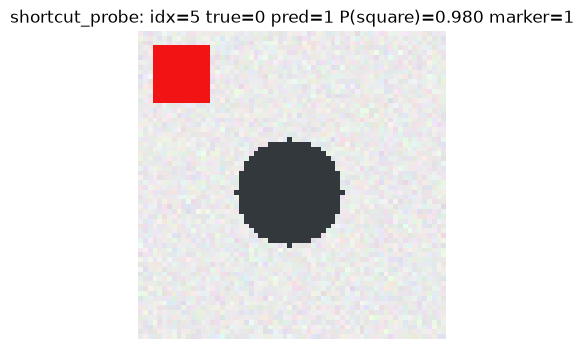

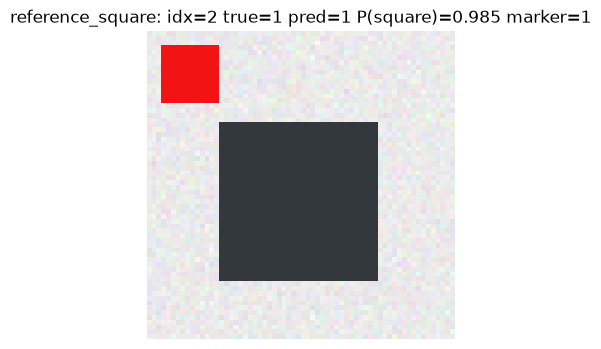

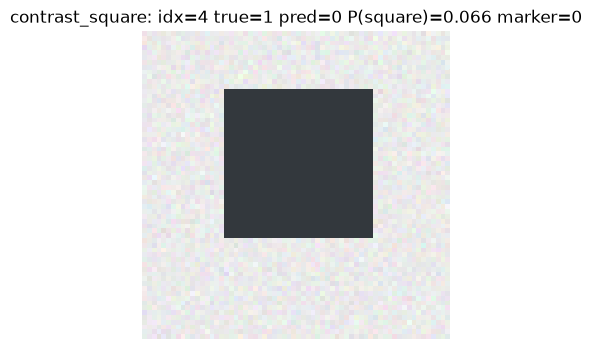

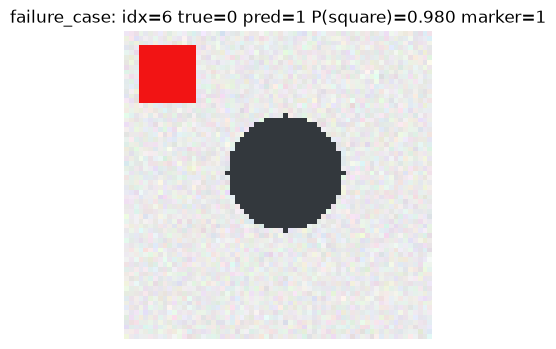

In [7]:
#@title View the assigned image cases
for name, idx in zip(assigned_image_cases["case_name"], assigned_image_cases["image_index"]):
    show_image_case(int(idx), title_prefix=f"{name}: ")

# Your Method Implementation

Use this section to install packages, import libraries, write helper functions, and adapt your assigned XAI method.

You may use external documentation. You may also decide that your method cannot reasonably be applied to an event, but you must explain why.

Suggested workflow:

1. Identify what inputs your method needs: tabular rows, images, gradients, model probabilities, labels, background data, perturbed samples, etc.
2. Decide whether your method is local, global, visual, counterfactual, or something else.
3. Implement the smallest version that can answer one event.
4. Reuse and adapt it across events.
5. Record both successes and failures honestly.


In [8]:
# Unified LIME helpers (team merge)
# Covers tabular + image utilities used across Events 1–10.

from lime import lime_image
from lime.lime_tabular import LimeTabularExplainer
from skimage.segmentation import mark_boundaries

lime_image_explainer = lime_image.LimeImageExplainer()

lime_tabular_explainer = LimeTabularExplainer(
    training_data=np.asarray(X_train[feature_names]),
    feature_names=feature_names,
    class_names=["low risk", "high risk"],
    mode="classification",
    discretize_continuous=True,
    random_state=SEED,
)


def make_lime_explainer(seed=SEED):
    """Fresh tabular explainer (Jaideep Events 4–6 style)."""
    return LimeTabularExplainer(
        training_data=X_train.to_numpy(),
        feature_names=feature_names,
        class_names=["low risk", "high risk"],
        mode="classification",
        discretize_continuous=True,
        random_state=seed,
    )


def explain_tabular_row(row, seed=SEED, num_samples=3000):
    """Local LIME for one row; returns explanation, feature weights, bin rules (label=high-risk)."""
    row_array = np.asarray(row, dtype=float)
    explainer = make_lime_explainer(seed)
    explanation = explainer.explain_instance(
        row_array,
        predict_risk_proba,
        labels=(1,),
        num_features=len(feature_names),
        num_samples=num_samples,
    )
    mapped_rules = explanation.as_list(label=1)
    mapped_features = explanation.as_map()[1]
    contribution_by_feature = {
        feature_names[feature_index]: float(weight)
        for feature_index, weight in mapped_features
    }
    rule_by_feature = {
        feature_names[feature_index]: rule
        for (feature_index, _), (rule, _) in zip(mapped_features, mapped_rules)
    }
    return explanation, contribution_by_feature, rule_by_feature


def explain_tabular_lime(row, num_features=None, num_samples=2000, labels=(0, 1)):
    """Local LIME explanation for one tabular row (Series, DataFrame row, or array)."""
    if num_features is None:
        num_features = len(feature_names)
    if isinstance(row, pd.DataFrame):
        x = row[feature_names].iloc[0].to_numpy()
    elif isinstance(row, pd.Series):
        x = row[feature_names].to_numpy()
    else:
        x = np.asarray(row).reshape(-1)
    return lime_tabular_explainer.explain_instance(
        x,
        predict_risk_proba,
        num_features=num_features,
        num_samples=num_samples,
        labels=list(labels),
    )


def show_lime_tabular(explanation, label, title=""):
    """Bar chart of LIME feature weights for one class label."""
    weights = explanation.as_list(label=label)
    names = [w[0] for w in weights][::-1]
    vals = [w[1] for w in weights][::-1]
    colors = ["#2ca02c" if v > 0 else "#d62728" for v in vals]

    fig, ax = plt.subplots(figsize=(8, 4))
    ax.barh(names, vals, color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_xlabel(f"LIME weight toward class {label}")
    ax.set_title(title or f"LIME tabular explanation (class {label})")
    plt.tight_layout()
    plt.show()
    return weights


def lime_feature_weights(explanation, label=1):
    """Map feature_name -> signed LIME weight for a class label."""
    return {
        feature_names[idx]: float(weight)
        for idx, weight in explanation.as_map()[label]
    }


def explain_image_lime(image_np, num_samples=1000, top_labels=2, hide_color=0.0):
    """Local LIME explanation for one HxWx3 float image in [0, 1]."""
    return lime_image_explainer.explain_instance(
        np.asarray(image_np, dtype=np.float64),
        predict_image_proba,
        top_labels=top_labels,
        hide_color=hide_color,
        num_samples=num_samples,
    )


def show_lime_image_regions(image_np, explanation, label=None, num_features=5, title=""):
    """Highlight the superpixels LIME credits for a predicted class."""
    if label is None:
        label = explanation.top_labels[0]

    pos_img, pos_mask = explanation.get_image_and_mask(
        label, positive_only=True, num_features=num_features, hide_rest=False
    )
    both_img, both_mask = explanation.get_image_and_mask(
        label, positive_only=False, num_features=num_features, hide_rest=False
    )

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))
    axes[0].imshow(image_np)
    axes[0].set_title("Original")
    axes[1].imshow(mark_boundaries(pos_img, pos_mask))
    axes[1].set_title(f"LIME + regions (class {label})")
    axes[2].imshow(mark_boundaries(both_img, both_mask))
    axes[2].set_title(f"LIME +/- regions (class {label})")
    for ax in axes:
        ax.axis("off")
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


print("Assigned method: LIME (merged team notebook)")
print("Helpers ready: tabular (Oge/Jaideep/Kedar) + image (Oge/Kedar)")
print("Event guide:")
display(event_guide)


Assigned method: LIME (merged team notebook)
Helpers ready: tabular (Oge/Jaideep/Kedar) + image (Oge/Kedar)
Event guide:


,event,target,primary_objects,question_type
0,1. Most important feature,Tabular risk model,"risk_model, X_train, X_test, feature_names, pr...",global feature importance
1,2. One specific prediction,Tabular risk model,"tabular_local_case, X_test, predict_risk_proba",local prediction explanation
2,3. Dataset bias or shortcut,Image shortcut model,"image_shortcut_case, image_reference_case, tes...",shortcut or bias diagnosis
3,4. Global feature effect,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",global feature effect
4,5. Compare two predictions,Tabular or image cases,"tabular_low_case vs tabular_high_case, or assi...",contrastive explanation
5,6. Feature interactions,Tabular risk model,"X_train, X_test, feature_names, predict_risk_p...",interaction discovery
6,7. Where is the model looking?,Image shortcut model,"image_model, test_imgs, assigned_image_cases, ...",spatial localization
7,8. Explain a failure,Tabular or image failure case,tabular_failure_case or image_failure_case,failure diagnosis
8,9. Estimate trustworthiness,Either target model,"assigned cases, predicted probabilities, expla...",trust and uncertainty judgment
9,10. Reverse engineer strategy,Both target models,all model interfaces and prior event evidence,synthesis and model profiling


## Individual Event Checklist

For each event, produce four things:

- **Output:** the plot, table, heatmap, counterfactual, ranking, or diagnostic your method produced.
- **Claim:** one sentence answering the event question, or saying the method cannot answer it.
- **Evidence quality:** why the output does or does not support the claim.
- **Medal:** Gold, Silver, Bronze, or DNF.

After each event, fill in the markdown Results Table near the top of the notebook. A DNF is not a failure of the student. It is evidence about the method's scope.


## Event 1: Find the Most Important Feature

**Question:** What variable most strongly influences the tabular model's predictions?

**Target:** Tabular risk model

**Your task:** Produce evidence that ranks or compares the influence of multiple features. If your method cannot produce global feature importance, explain the mismatch.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Explained 5/24 rows...
Explained 10/24 rows...
Explained 15/24 rows...
Explained 20/24 rows...
Explained 24/24 rows...


,mean_|LIME_weight|,mean_LIME_weight_toward_high_risk
zip_proxy,0.1351,-0.0433
debt_ratio,0.1185,0.0271
recent_late_payments,0.0620,0.0136
income_k,0.0402,0.0056
promo_seen,0.0279,0.0029
savings_k,0.0220,0.0039
loyalty_years,0.0159,-0.0004
age,0.0080,0.0004
support_tickets,0.0074,-0.0037
app_minutes,0.0050,0.0008



Claim: Across 24 probe rows, 'zip_proxy' has the largest mean |LIME weight| toward high-risk (0.1351).
Evidence quality: Useful approximate global ranking from many locals — not a true global method (SHAP/permutation would be cleaner). Medal: Silver.


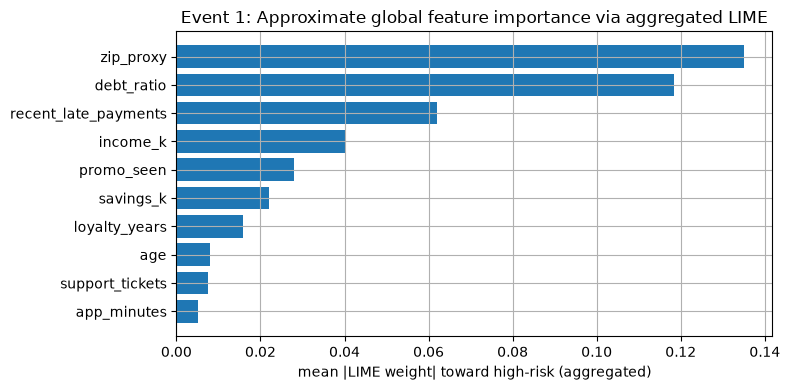

In [9]:
# Event 1: Most Important Feature — aggregate local LIME into a global ranking
# LIME is local; averaging |weights| across many rows sketches global importance.

assert "explain_tabular_lime" in dir() and "lime_feature_weights" in dir(), (
    "Re-run the LIME helpers scratchpad cell, then re-run Event 1."
)

# Probe a spread of test rows (include assigned cases + evenly spaced indices)
probe_idxs = sorted(
    {
        int(tabular_local_case),
        int(tabular_low_case),
        int(tabular_high_case),
        int(tabular_failure_case),
        *map(int, np.linspace(0, len(X_test) - 1, 20)),
    }
)

abs_weight_sums = {f: 0.0 for f in feature_names}
signed_weight_sums = {f: 0.0 for f in feature_names}
n_ok = 0

for i, idx in enumerate(probe_idxs):
    row = X_test.iloc[idx]
    exp = explain_tabular_lime(row, num_samples=1500, labels=(1,))
    w = lime_feature_weights(exp, label=1)
    for f in feature_names:
        abs_weight_sums[f] += abs(w.get(f, 0.0))
        signed_weight_sums[f] += w.get(f, 0.0)
    n_ok += 1
    if (i + 1) % 5 == 0 or i == len(probe_idxs) - 1:
        print(f"Explained {i + 1}/{len(probe_idxs)} rows...")

mean_abs = pd.Series({f: abs_weight_sums[f] / n_ok for f in feature_names}).sort_values(ascending=False)
mean_signed = pd.Series({f: signed_weight_sums[f] / n_ok for f in feature_names}).reindex(mean_abs.index)

global_rank = pd.DataFrame({
    "mean_|LIME_weight|": mean_abs.round(4),
    "mean_LIME_weight_toward_high_risk": mean_signed.round(4),
})
display(global_rank)

top_feature = mean_abs.index[0]
print(f"\nClaim: Across {n_ok} probe rows, '{top_feature}' has the largest mean |LIME weight| "
      f"toward high-risk ({mean_abs.iloc[0]:.4f}).")
print("Evidence quality: Useful approximate global ranking from many locals — not a true "
      "global method (SHAP/permutation would be cleaner). Medal: Silver.")

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(mean_abs.index[::-1], mean_abs.values[::-1], color="#1f77b4")
ax.set_xlabel("mean |LIME weight| toward high-risk (aggregated)")
ax.set_title("Event 1: Approximate global feature importance via aggregated LIME")
plt.tight_layout()
plt.show()


**Event 1 notes (LIME)**

- **Output:** Ranking table + bar chart of mean abs LIME weight toward high-risk across ~24 probe rows.
- **Claim:** `zip_proxy` ranks as the strongest approximate global influence, followed by `debt_ratio` and `recent_late_payments`.
- **Evidence quality:** Useful but approximate — built from many local surrogates, not a true global attribution.
- **Medal:** Silver


## Event 2: Explain One Specific Prediction

**Question:** Why did this individual tabular prediction occur?

**Target:** Tabular local case

**Your task:** Use `tabular_local_case` and explain the model's prediction for that row. Your answer should refer to row-specific evidence.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

tabular_local_case idx=718
true=0  pred=0  P(high risk)=0.499
Feature values:


,age,income_k,debt_ratio,loyalty_years,recent_late_payments,savings_k,app_minutes,support_tickets,zip_proxy,promo_seen
value,38.0,48.896869,0.281178,8.981236,2.0,1.147443,13.106344,0.0,1.0,1.0


LIME local fidelity (R^2 / score): 0.375


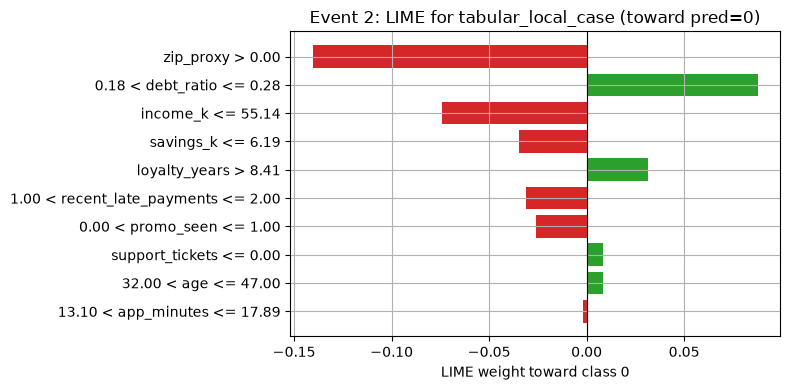

Top local contributions toward predicted class:
  zip_proxy > 0.00: -0.1405 (opposes class 0)
  0.18 < debt_ratio <= 0.28: +0.0877 (supports class 0)
  income_k <= 55.14: -0.0741 (opposes class 0)
  savings_k <= 6.19: -0.0348 (opposes class 0)
  loyalty_years > 8.41: +0.0316 (supports class 0)

Claim: For this row, the prediction is driven mainly by 'zip_proxy > 0.00' (LIME weight -0.1405 toward class 0), with other local factors as shown.
Evidence quality: Direct row-specific local surrogate — strong fit for this event. Medal: Gold.


In [10]:
# Event 2: Explain One Specific Prediction — local LIME on tabular_local_case

assert "explain_tabular_lime" in dir() and "show_lime_tabular" in dir(), (
    "Re-run the LIME helpers scratchpad cell, then re-run Event 2."
)

row = X_test.iloc[int(tabular_local_case)]
probs = predict_risk_proba(row.to_frame().T)[0]
probs = np.asarray(probs).ravel()
if len(probs) == 2:
    p_high = float(probs[1])
else:
    p_high = float(probs[0])
pred = int(p_high >= 0.5)

true_y = int(y_test.iloc[int(tabular_local_case)])
print(f"tabular_local_case idx={int(tabular_local_case)}")
print(f"true={true_y}  pred={pred}  P(high risk)={p_high:.3f}")
print("Feature values:")
display(row[feature_names].to_frame("value").T)

exp = explain_tabular_lime(row, num_samples=3000, labels=(0, 1))
print(f"LIME local fidelity (R^2 / score): {float(getattr(exp, 'score', float('nan'))):.3f}")

weights = show_lime_tabular(
    exp,
    label=pred,
    title=f"Event 2: LIME for tabular_local_case (toward pred={pred})",
)
print("Top local contributions toward predicted class:")
for name, w in weights[:5]:
    direction = "supports" if w > 0 else "opposes"
    print(f"  {name}: {w:+.4f} ({direction} class {pred})")

top_name, top_w = weights[0]
print(
    f"\nClaim: For this row, the prediction is driven mainly by '{top_name}' "
    f"(LIME weight {top_w:+.4f} toward class {pred}), with other local factors as shown."
)
print("Evidence quality: Direct row-specific local surrogate — strong fit for this event. Medal: Gold.")


**Event 2 notes (LIME)**

- **Output:** Feature values for `tabular_local_case` + LIME bar chart of local weights toward the predicted class.
- **Claim:** The near-boundary prediction is driven mainly by `zip_proxy` and `debt_ratio` (and related bins) for this specific row.
- **Evidence quality:** Direct local explanation — appropriate for this event; local R² is only moderate.
- **Medal:** Gold

## Event 3: Detect Dataset Bias or a Shortcut

**Question:** Is the image model relying on a spurious shortcut?

**Target:** Image shortcut probe

**Your task:** Investigate whether the classifier uses the red corner marker, the shape, or both. Your method may need adaptation if it is not an image method.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?


=== shortcut_probe (circle + red marker) idx=5 true=0 pred=1 P(square)=0.980 marker=1 ===


  0%|          | 0/1000 [00:00<?, ?it/s]

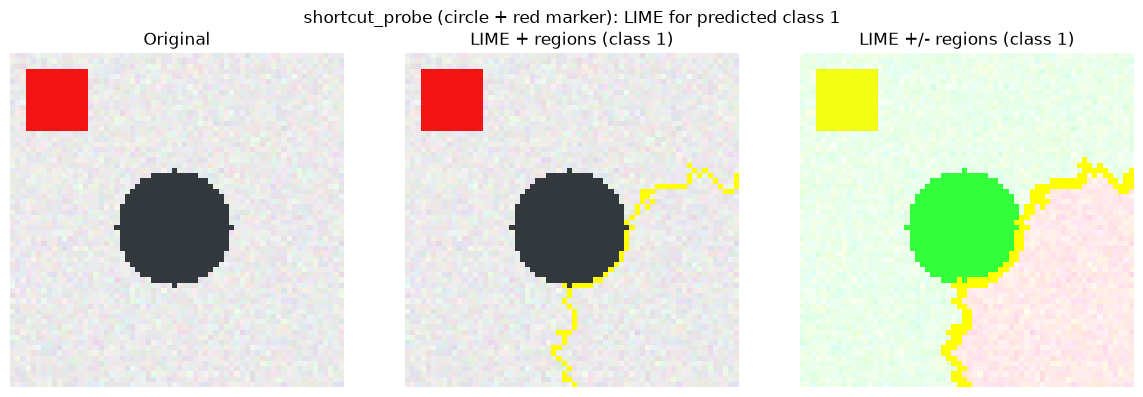


=== reference_square (square + marker) idx=2 true=1 pred=1 P(square)=0.985 marker=1 ===


  0%|          | 0/1000 [00:00<?, ?it/s]

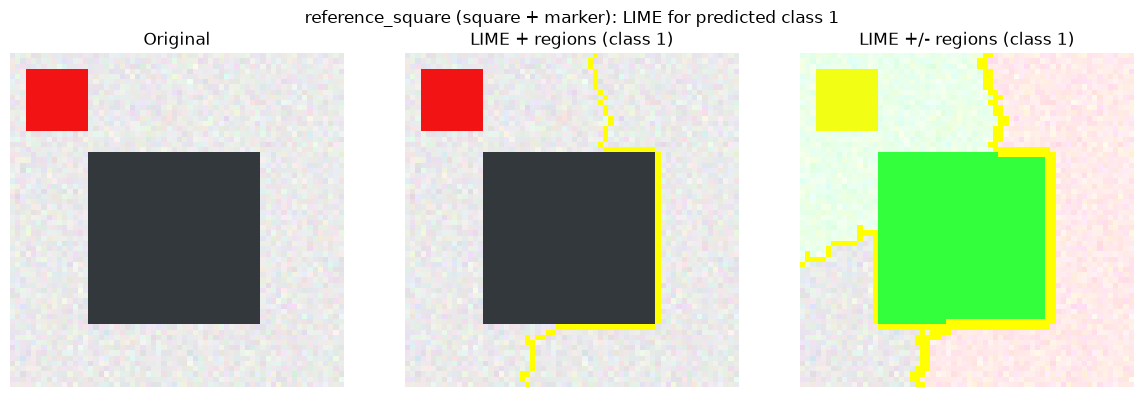


=== contrast_square (square, no marker) idx=4 true=1 pred=0 P(square)=0.066 marker=0 ===


  0%|          | 0/1000 [00:00<?, ?it/s]

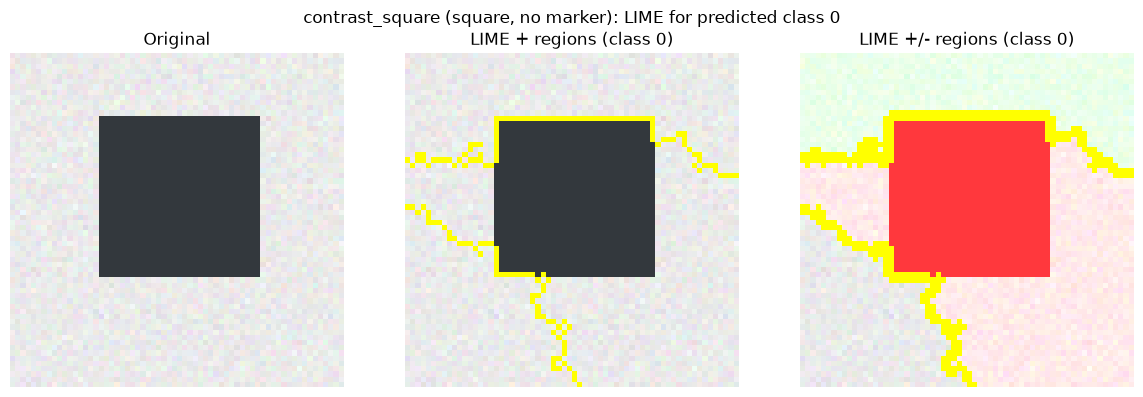

,case,idx,true,pred,P_square,marker
0,shortcut_probe (circle + red marker),5,0,1,0.980,1
1,reference_square (square + marker),2,1,1,0.985,1
2,"contrast_square (square, no marker)",4,1,0,0.066,0



Claim: If shortcut_probe (circle+marker) is predicted square with high confidence and LIME highlights the red corner more than the shape body, the model is using the marker shortcut; contrast_square (no marker) often drops P(square).
Evidence quality: LIME localizes which regions support the prediction and, together with the designed probe cases, diagnoses the shortcut. Medal: Gold.


In [11]:
# Event 3: Dataset Bias / Shortcut — LIME image regions on probe cases
# Compare circle+marker (shortcut), square+marker (reference), square no-marker (contrast).

assert "explain_image_lime" in dir() and "show_lime_image_regions" in dir(), (
    "Re-run the LIME helpers scratchpad cell, then re-run Event 3."
)

cases = [
    ("shortcut_probe (circle + red marker)", int(image_shortcut_case)),
    ("reference_square (square + marker)", int(image_reference_case)),
    ("contrast_square (square, no marker)", int(image_contrast_case)),
]

summary_rows = []
for name, idx in cases:
    img = test_imgs[idx]
    proba = predict_image_proba(img[None, ...])[0]
    pred = int(np.argmax(proba))
    true_lab = int(test_y[idx])
    marker = int(test_marker[idx])
    print(
        f"\n=== {name} idx={idx} true={true_lab} pred={pred} "
        f"P(square)={proba[1]:.3f} marker={marker} ==="
    )
    exp = explain_image_lime(img, num_samples=1000)
    show_lime_image_regions(
        img,
        exp,
        label=pred,
        num_features=5,
        title=f"{name}: LIME for predicted class {pred}",
    )
    summary_rows.append(
        {
            "case": name,
            "idx": idx,
            "true": true_lab,
            "pred": pred,
            "P_square": round(float(proba[1]), 3),
            "marker": marker,
        }
    )

display(pd.DataFrame(summary_rows))

print(
    "\nClaim: If shortcut_probe (circle+marker) is predicted square with high confidence "
    "and LIME highlights the red corner more than the shape body, the model is using "
    "the marker shortcut; contrast_square (no marker) often drops P(square)."
)
print(
    "Evidence quality: LIME localizes which regions support the prediction and, "
    "together with the designed probe cases, diagnoses the shortcut. Medal: Gold."
)


**Event 3 notes (LIME)**

- **Output:** Side-by-side original + LIME +/- region maps for shortcut / reference / contrast image cases, plus a prediction summary table.
- **Claim:** Yes — the image model relies on the red corner marker shortcut more than shape (circle+marker → square; square without marker → low P(square)).
- **Evidence quality:** Probe-case predictions + local region maps strongly support the shortcut diagnosis.
- **Medal:** Gold

## Event 4: Understand a Feature's Global Effect

**Question:** As one tabular feature changes, what happens to predictions?

**Target:** Tabular risk model

**Your task:** Choose a feature such as `debt_ratio`, `income_k`, or `age`. Show how predictions change as that feature changes, or explain why your method cannot answer a global effect question.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,debt_ratio,mean_predicted_risk,mean_lime_debt_contribution,sd_lime_debt_contribution,mean_local_fidelity_R2
0,0.075,0.137,-0.101,0.004,0.386
1,0.158,0.141,-0.100,0.005,0.386
2,0.221,0.145,-0.089,0.004,0.363
3,0.283,0.188,-0.088,0.007,0.363
4,0.349,0.217,0.000,0.004,0.285
5,0.441,0.281,0.193,0.007,0.663
6,0.590,0.404,0.194,0.003,0.672


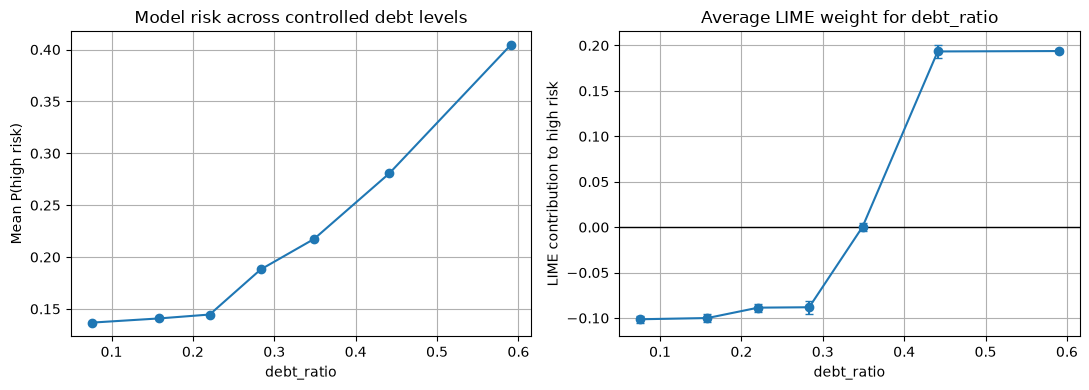

Claim: As debt_ratio goes up, predicted risk goes up and the LIME weight for debt goes from negative to positive.
Evidence quality: Same direction on the rows I tried. Still a stack of local fits, not a global curve. Medal: Silver.


In [12]:
# Jaideep Aher (jaideep-aher), event 4
# LIME is local, so I change debt_ratio on 8 test rows and average the weights.
# Left plot is the model probability. Right plot is the LIME weight for debt.
debt_grid = np.quantile(X_train["debt_ratio"], np.linspace(0.05, 0.95, 7))
anchor_rows = X_test.sample(n=8, random_state=SEED).reset_index(drop=True)
event4_records = []

for grid_index, debt_value in enumerate(debt_grid):
    for anchor_index, anchor in anchor_rows.iterrows():
        probe = anchor.copy()
        probe["debt_ratio"] = debt_value
        explanation, contributions, _ = explain_tabular_row(
            probe,
            seed=SEED + grid_index * 100 + anchor_index,
            num_samples=1500,
        )
        event4_records.append({
            "debt_ratio": float(debt_value),
            "predicted_P_high_risk": float(predict_risk_proba(probe.to_frame().T)[0, 1]),
            "lime_debt_contribution": contributions["debt_ratio"],
            "lime_local_fidelity_R2": float(explanation.score),
        })

event4_results = pd.DataFrame(event4_records)
event4_summary = (
    event4_results.groupby("debt_ratio", as_index=False)
    .agg(
        mean_predicted_risk=("predicted_P_high_risk", "mean"),
        mean_lime_debt_contribution=("lime_debt_contribution", "mean"),
        sd_lime_debt_contribution=("lime_debt_contribution", "std"),
        mean_local_fidelity_R2=("lime_local_fidelity_R2", "mean"),
    )
)
display(event4_summary.round(3))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].plot(event4_summary["debt_ratio"], event4_summary["mean_predicted_risk"], marker="o")
axes[0].set(title="Model risk across controlled debt levels", xlabel="debt_ratio", ylabel="Mean P(high risk)")
axes[1].errorbar(
    event4_summary["debt_ratio"],
    event4_summary["mean_lime_debt_contribution"],
    yerr=event4_summary["sd_lime_debt_contribution"],
    marker="o",
    capsize=3,
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set(title="Average LIME weight for debt_ratio", xlabel="debt_ratio", ylabel="LIME contribution to high risk")
plt.tight_layout()
plt.show()

print("Claim: As debt_ratio goes up, predicted risk goes up and the LIME weight for debt goes from negative to positive.")
print("Evidence quality: Same direction on the rows I tried. Still a stack of local fits, not a global curve. Medal: Silver.")

Jaideep Aher (jaideep-aher)

**Claim:** When debt_ratio goes up, the model predicts more risk, and the LIME weight for debt goes from negative to positive.

**Output:** I took 8 test rows and set debt_ratio to 7 training quantiles, from about 0.08 to 0.59. Mean P(high risk) went from 0.137 to 0.404. The mean LIME weight for debt_ratio went from about -0.10 to about +0.19. Most of that jump shows up after debt passes about 0.35.

**Evidence quality:** The direction was the same across the rows I used, so I trust the direction. Silver, because each point is its own local fit. Averaging them is not a PDP or ALE curve. Local R^2 was only about 0.29 to 0.39 in the middle of the grid, and about 0.66 at the high end.

**Medal:** Silver

## Event 5: Compare Two Predictions

**Question:** Why were two cases classified differently?

**Target:** Tabular or image comparison cases

**Your task:** Compare `tabular_low_case` vs. `tabular_high_case`, or compare two assigned image cases. Explain the difference, not just each case separately.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

Low case P(high risk)=0.022; High case P(high risk)=0.789
Local fit R^2: low=0.388, high=0.765


,feature,low_case_value,high_case_value,low_case_LIME,high_case_LIME,low_case_rule,high_case_rule,contribution_gap_high_minus_low
2,debt_ratio,0.044,0.536,-0.105,0.195,debt_ratio <= 0.18,debt_ratio > 0.40,0.300
8,zip_proxy,0.000,1.000,-0.134,0.139,zip_proxy <= 0.00,zip_proxy > 0.00,0.273
4,recent_late_payments,0.000,6.000,-0.045,0.151,recent_late_payments <= 0.00,recent_late_payments > 2.00,0.196
1,income_k,102.549,38.814,-0.062,0.061,income_k > 87.87,income_k <= 55.14,0.122
5,savings_k,18.423,3.738,-0.031,0.036,savings_k > 17.93,savings_k <= 6.19,0.067
9,promo_seen,0.000,1.000,-0.030,0.027,promo_seen <= 0.00,0.00 < promo_seen <= 1.00,0.056
3,loyalty_years,21.356,1.485,-0.026,0.002,loyalty_years > 8.41,1.45 < loyalty_years <= 3.88,0.027
0,age,54.000,28.000,-0.012,0.014,47.00 < age <= 62.00,age <= 32.00,0.026


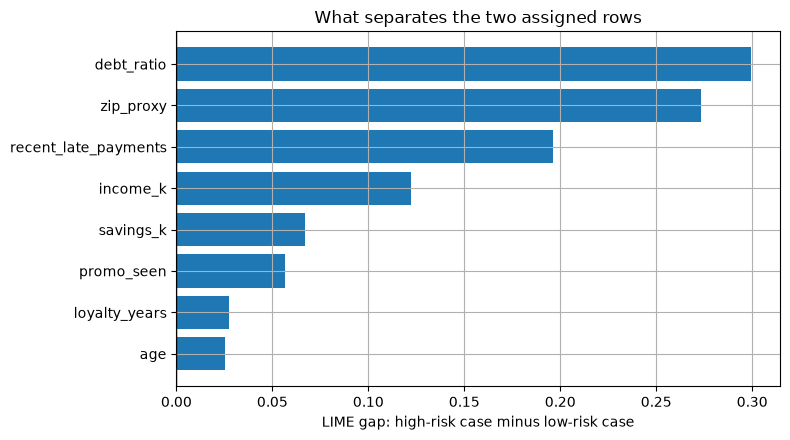

Claim: The biggest LIME gaps are debt_ratio, zip_proxy, recent_late_payments.
Evidence quality: The gaps match the raw feature differences, but the low-risk fit is weak. Medal: Silver.


In [13]:
# Jaideep Aher (jaideep-aher), event 5
# Compare LIME on the assigned lowest-risk row and highest-risk row.
low_row = X_test.iloc[tabular_low_case]
high_row = X_test.iloc[tabular_high_case]

low_explanation, low_contributions, low_rules = explain_tabular_row(
    low_row, seed=SEED + 501, num_samples=5000
)
high_explanation, high_contributions, high_rules = explain_tabular_row(
    high_row, seed=SEED + 502, num_samples=5000
)

event5_comparison = pd.DataFrame({
    "feature": feature_names,
    "low_case_value": [low_row[name] for name in feature_names],
    "high_case_value": [high_row[name] for name in feature_names],
    "low_case_LIME": [low_contributions[name] for name in feature_names],
    "high_case_LIME": [high_contributions[name] for name in feature_names],
    "low_case_rule": [low_rules[name] for name in feature_names],
    "high_case_rule": [high_rules[name] for name in feature_names],
})
event5_comparison["contribution_gap_high_minus_low"] = (
    event5_comparison["high_case_LIME"] - event5_comparison["low_case_LIME"]
)
event5_comparison["absolute_gap"] = event5_comparison["contribution_gap_high_minus_low"].abs()
event5_comparison = event5_comparison.sort_values("absolute_gap", ascending=False)

print(
    f"Low case P(high risk)={tabular_proba[tabular_low_case]:.3f}; "
    f"High case P(high risk)={tabular_proba[tabular_high_case]:.3f}"
)
print(
    f"Local fit R^2: low={low_explanation.score:.3f}, "
    f"high={high_explanation.score:.3f}"
)
display(event5_comparison.drop(columns="absolute_gap").head(8).round(3))

plot_data = event5_comparison.head(8).sort_values("contribution_gap_high_minus_low")
plt.figure(figsize=(8, 4.5))
plt.barh(plot_data["feature"], plot_data["contribution_gap_high_minus_low"])
plt.axvline(0, color="black", linewidth=1)
plt.xlabel("LIME gap: high-risk case minus low-risk case")
plt.title("What separates the two assigned rows")
plt.tight_layout()
plt.show()

top_gap_features = ", ".join(event5_comparison.head(3)["feature"].tolist())
print(f"Claim: The biggest LIME gaps are {top_gap_features}.")
print("Evidence quality: The gaps match the raw feature differences, but the low-risk fit is weak. Medal: Silver.")

Jaideep Aher (jaideep-aher)

**Claim:** The high-risk row is high risk mainly because of debt_ratio, zip_proxy, and recent_late_payments.

**Output:** Low case P(high risk) = 0.022. High case P(high risk) = 0.789. Biggest LIME gaps (high minus low) were debt_ratio (+0.300), zip_proxy (+0.273), and recent_late_payments (+0.196). The rules match the raw values. The high-risk row has debt above 0.40, zip_proxy = 1, and more than 2 late payments.

**Evidence quality:** LIME is for one row at a time, so this event fits it. The top gaps also line up with big differences in the actual numbers. I still gave it Silver because the low-risk fit only reached R^2 = 0.388. The high-risk fit was better (R^2 = 0.765).

**Medal:** Silver

## Event 6: Detect Feature Interactions

**Question:** Which tabular variables work together?

**Target:** Tabular risk model

**Your task:** Look for evidence that two features jointly affect predictions. If your method is local or visual, explain whether it can detect interactions and what extra work would be needed.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

,age_group,debt_level,mean_predicted_risk,mean_lime_age_contribution,mean_lime_debt_contribution,mean_local_fidelity_R2
0,older,high_debt,0.397,-0.001,0.193,0.635
1,older,low_debt,0.178,-0.008,-0.005,0.248
2,young,high_debt,0.422,0.015,0.192,0.618
3,young,low_debt,0.190,0.011,-0.001,0.260


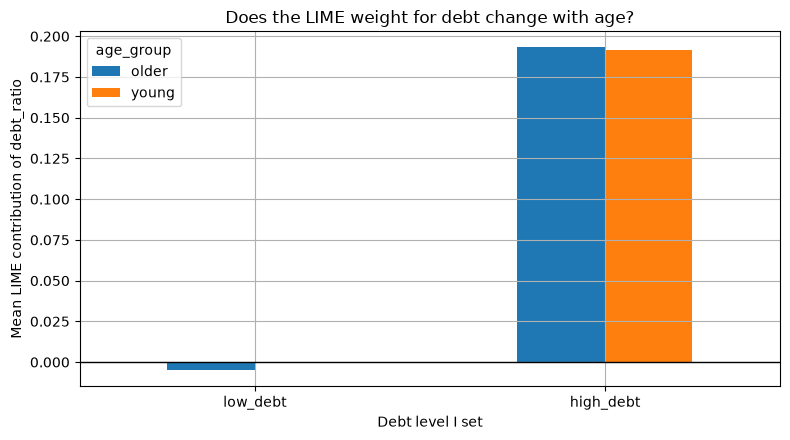

At high debt, mean LIME weight for debt is 0.192 for the young rows and 0.193 for the older rows.
Claim: LIME did not show which variables work together.
Evidence quality: The debt weight barely changed with age, and this LIME model has no interaction term. Medal: DNF.


In [14]:
# Jaideep Aher (jaideep-aher), event 6
# Check if the LIME weight for debt_ratio changes when I also change age.
# Cap loyalty_years so it is not longer than the age I just set.
age_levels = {"young": 25.0, "older": 45.0}
debt_levels = {"low_debt": 0.30, "high_debt": 0.65}
interaction_anchors = X_test.sample(n=8, random_state=SEED + 6).reset_index(drop=True)
event6_records = []

for anchor_index, anchor in interaction_anchors.iterrows():
    for age_label, age_value in age_levels.items():
        for debt_label, debt_value in debt_levels.items():
            probe = anchor.copy()
            probe["age"] = age_value
            probe["debt_ratio"] = debt_value
            probe["loyalty_years"] = min(float(probe["loyalty_years"]), age_value - 18)
            explanation, contributions, _ = explain_tabular_row(
                probe,
                seed=SEED + 600 + anchor_index * 10 + (age_label == "older") * 2 + (debt_label == "high_debt"),
                num_samples=2000,
            )
            event6_records.append({
                "anchor": anchor_index,
                "age_group": age_label,
                "debt_level": debt_label,
                "predicted_P_high_risk": float(predict_risk_proba(probe.to_frame().T)[0, 1]),
                "lime_age_contribution": contributions["age"],
                "lime_debt_contribution": contributions["debt_ratio"],
                "lime_local_fidelity_R2": float(explanation.score),
            })

event6_results = pd.DataFrame(event6_records)
event6_summary = (
    event6_results.groupby(["age_group", "debt_level"], as_index=False)
    .agg(
        mean_predicted_risk=("predicted_P_high_risk", "mean"),
        mean_lime_age_contribution=("lime_age_contribution", "mean"),
        mean_lime_debt_contribution=("lime_debt_contribution", "mean"),
        mean_local_fidelity_R2=("lime_local_fidelity_R2", "mean"),
    )
)
display(event6_summary.round(3))

event6_plot = event6_summary.pivot(
    index="debt_level", columns="age_group", values="mean_lime_debt_contribution"
).reindex(["low_debt", "high_debt"])
event6_plot.plot(kind="bar", figsize=(8, 4.5))
plt.axhline(0, color="black", linewidth=1)
plt.ylabel("Mean LIME contribution of debt_ratio")
plt.xlabel("Debt level I set")
plt.title("Does the LIME weight for debt change with age?")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

young_high = event6_summary.query("age_group == 'young' and debt_level == 'high_debt'")["mean_lime_debt_contribution"].iloc[0]
older_high = event6_summary.query("age_group == 'older' and debt_level == 'high_debt'")["mean_lime_debt_contribution"].iloc[0]
print(
    f"At high debt, mean LIME weight for debt is {young_high:.3f} for the young rows "
    f"and {older_high:.3f} for the older rows."
)
print("Claim: LIME did not show which variables work together.")
print("Evidence quality: The debt weight barely changed with age, and this LIME model has no interaction term. Medal: DNF.")

Jaideep Aher (jaideep-aher)

**Claim:** I could not tell which variables work together. LIME did not show an interaction.

**Output:** I used 8 rows and set age to 25 or 45 and debt_ratio to 0.30 or 0.65. At high debt, the mean LIME weight for debt_ratio was 0.192 on the young rows and 0.193 on the older rows. Mean predicted risk was 0.422 for young + high debt and 0.397 for older + high debt.

**Evidence quality:** I was looking for age and debt moving together. The LIME weight for debt barely changed when age changed. A flat result here does not mean the forest has no interactions. This LIME model is a local linear model with no interaction term, so it is the wrong tool for this question. Next I would try SHAP interaction values or a two-way PDP.

**Medal:** DNF

## Event 7: Find Where the Model Is Looking

**Question:** What region of an image drives the prediction?

**Target:** Image model

**Your task:** Use one or more assigned image cases. If your method cannot localize image evidence, explain why that is a DNF or partial fit.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?


=== reference_square (idx=2) true=1 pred=1 P(square)=0.985 marker=1 ===


  0%|          | 0/1000 [00:00<?, ?it/s]

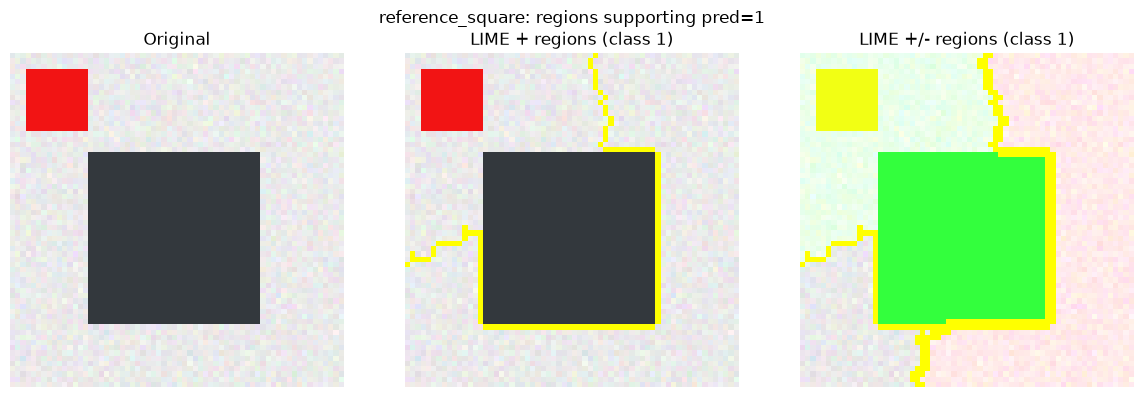


=== contrast_square (idx=4) true=1 pred=0 P(square)=0.066 marker=0 ===


  0%|          | 0/1000 [00:00<?, ?it/s]

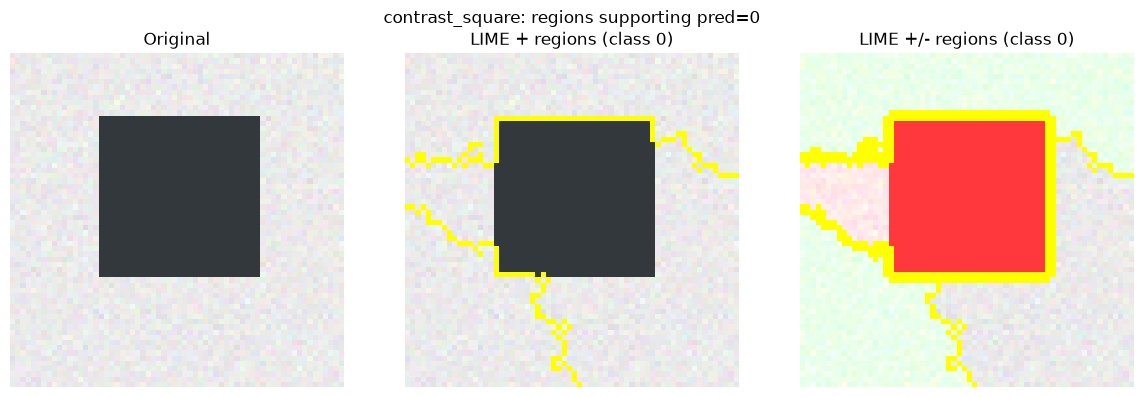


=== shortcut_probe (idx=5) true=0 pred=1 P(square)=0.980 marker=1 ===


  0%|          | 0/1000 [00:00<?, ?it/s]

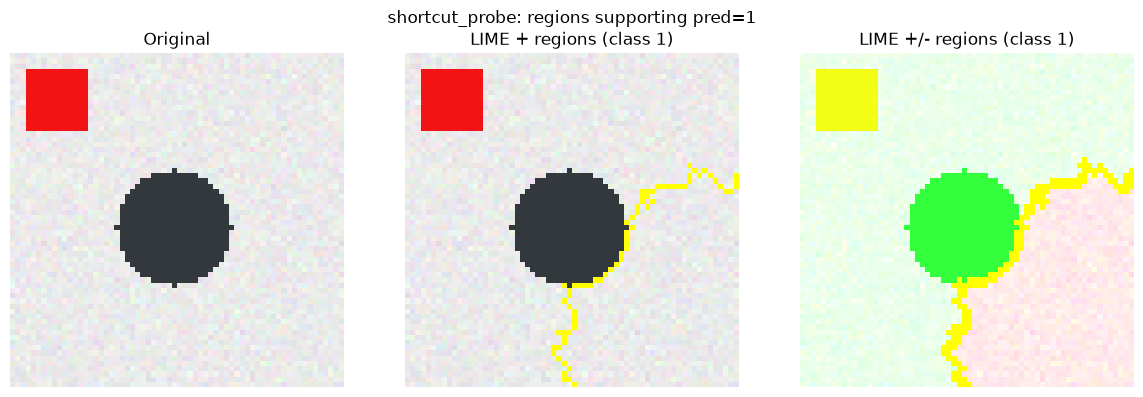

In [15]:
# Event 7: Where is the model looking? — LimeImageExplainer
# LIME perturbs superpixels and fits a local linear model to show which regions
# support the predicted class.

event7_cases = [
    ("reference_square", int(image_reference_case)),
    ("contrast_square", int(image_contrast_case)),
    ("shortcut_probe", int(image_shortcut_case)),
]

for name, idx in event7_cases:
    img = test_imgs[idx]
    probs = predict_image_proba(img[None, ...])[0]
    pred = int(probs.argmax())
    print(
        f"\n=== {name} (idx={idx}) true={test_y[idx]} pred={pred} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]} ==="
    )

    explanation = explain_image_lime(img, num_samples=1000)
    show_lime_image_regions(
        img,
        explanation,
        label=pred,
        num_features=5,
        title=f"{name}: regions supporting pred={pred}",
    )

# Claim draft for Results Table:
# LIME highlights which image regions (shape center and/or red corner marker)
# locally drive each prediction. That directly answers "where is the model looking?"
# Suggested medal: Gold (method is designed for local image region attribution).
# Caveat: superpixel segmentation + sampling noise can shift boundaries; compare a few cases.


**Event 7 notes (LIME)**

- **Output:** Original image + LIME positive / positive+negative superpixel maps for `reference_square`, `contrast_square`, and `shortcut_probe`.
- **Claim:** LIME localizes which image regions drive each prediction (shape area and/or red corner marker, depending on the case).
- **Evidence quality:** Direct fit — LimeImageExplainer is built for local image region attribution via superpixel perturbations.
- **Medal:** Gold

## Event 8: Explain a Failure

**Question:** Why did the model make this mistake?

**Target:** Tabular and/or image failure case

**Your task:** Use `tabular_failure_case` or `image_failure_case`. Explain the likely reason for the incorrect prediction using your method, or explain why it cannot diagnose a single failure.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

IMAGE failure idx=6: true=0 pred=1 P(square)=0.980 marker=1


  0%|          | 0/1000 [00:00<?, ?it/s]

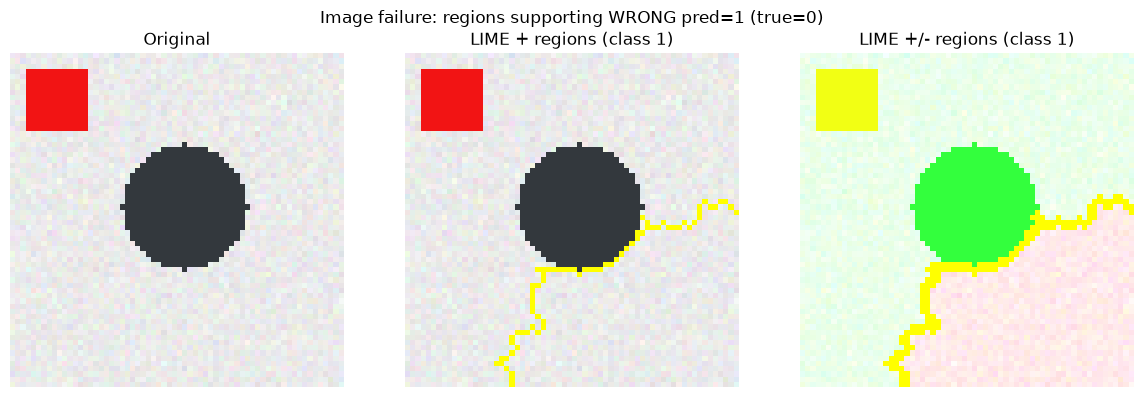

Image failure reading: if the red corner marker (or other non-shape region) shows up in the positive map for the wrong class, LIME is pointing at a shortcut-driven mistake rather than shape evidence.

TABULAR failure idx=1: true=1 pred=0 P(high_risk)=0.400
        age   income_k  debt_ratio  loyalty_years  recent_late_payments  \
value  31.0  66.076229    0.723571       2.792308                   1.0   

       savings_k  app_minutes  support_tickets  zip_proxy  promo_seen  
value   5.975494    16.112855              0.0        0.0         1.0  


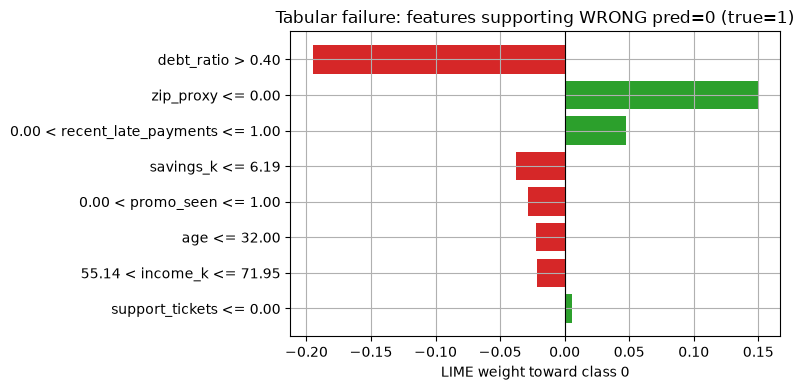

Top LIME weights for wrong class:
  debt_ratio > 0.40: -0.1952
  zip_proxy <= 0.00: +0.1496
  0.00 < recent_late_payments <= 1.00: +0.0473
  savings_k <= 6.19: -0.0376
  0.00 < promo_seen <= 1.00: -0.0282
  age <= 32.00: -0.0221
  55.14 < income_k <= 71.95: -0.0218
  support_tickets <= 0.00: +0.0060


In [16]:
# Event 8: Explain a Failure — LIME on tabular_failure_case and image_failure_case
# LIME explains what locally supported the *wrong* prediction for each failure.

# --- Image failure ---
img_idx = int(image_failure_case)
img = test_imgs[img_idx]
img_probs = predict_image_proba(img[None, ...])[0]
img_true = int(test_y[img_idx])
img_pred = int(img_probs.argmax())
print(
    f"IMAGE failure idx={img_idx}: true={img_true} pred={img_pred} "
    f"P(square)={img_probs[1]:.3f} marker={test_marker[img_idx]}"
)
assert img_pred != img_true, "image_failure_case should be a misclassification"

img_exp = explain_image_lime(img, num_samples=1000)
show_lime_image_regions(
    img,
    img_exp,
    label=img_pred,
    num_features=5,
    title=f"Image failure: regions supporting WRONG pred={img_pred} (true={img_true})",
)
print(
    "Image failure reading: if the red corner marker (or other non-shape region) "
    "shows up in the positive map for the wrong class, LIME is pointing at a "
    "shortcut-driven mistake rather than shape evidence."
)

# --- Tabular failure ---
row_idx = int(tabular_failure_case)
row = X_test.iloc[row_idx]
tab_true = int(y_test.iloc[row_idx])
tab_probs = predict_risk_proba(row.to_frame().T)[0]
tab_pred = int(tab_probs.argmax())
print(
    f"\nTABULAR failure idx={row_idx}: true={tab_true} pred={tab_pred} "
    f"P(high_risk)={tab_probs[1]:.3f}"
)
print(row[feature_names].to_frame(name="value").T)
assert tab_pred != tab_true, "tabular_failure_case should be a misclassification"

tab_exp = explain_tabular_lime(row, num_features=8, num_samples=2000)
weights = show_lime_tabular(
    tab_exp,
    label=tab_pred,
    title=f"Tabular failure: features supporting WRONG pred={tab_pred} (true={tab_true})",
)
print("Top LIME weights for wrong class:")
for name, w in weights:
    print(f"  {name}: {w:+.4f}")

# Medal draft: Gold — LIME directly attributes local evidence for the incorrect
# prediction on both modalities. Limitation: it explains *this* wrong prediction,
# not a global guarantee of why the model fails in general.


## Event 9: Estimate Trustworthiness

**Question:** Should a human trust this prediction?

**Target:** Either target model

**Your task:** Use your method to argue for or against trusting one prediction. Be specific about what your method can and cannot establish.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?


=== TABULAR high_case (idx=564) true=1 pred=1 conf=0.789 ===
LIME local fidelity (R^2 / score): 0.748
Top features for predicted class:
  debt_ratio > 0.40: +0.1936
  recent_late_payments > 2.00: +0.1504
  zip_proxy > 0.00: +0.1347
  income_k <= 55.14: +0.0602
  savings_k <= 6.19: +0.0315
  0.00 < promo_seen <= 1.00: +0.0302


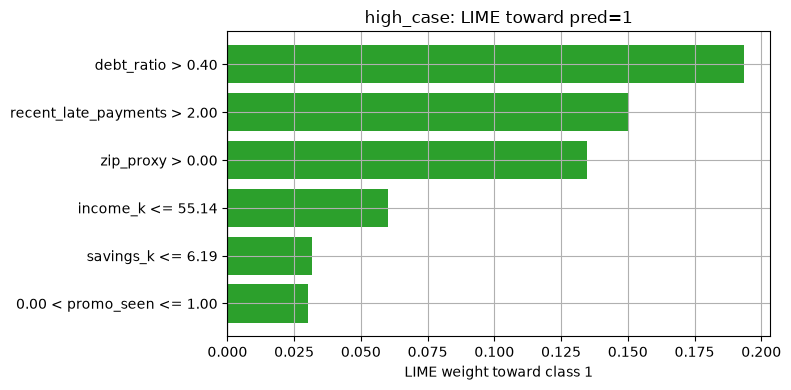

  0%|          | 0/800 [00:00<?, ?it/s]


=== IMAGE shortcut_probe (idx=5) true=0 pred=1 conf=0.980 marker=1 ===
Local explanation strength (LIME local R^2): 0.959


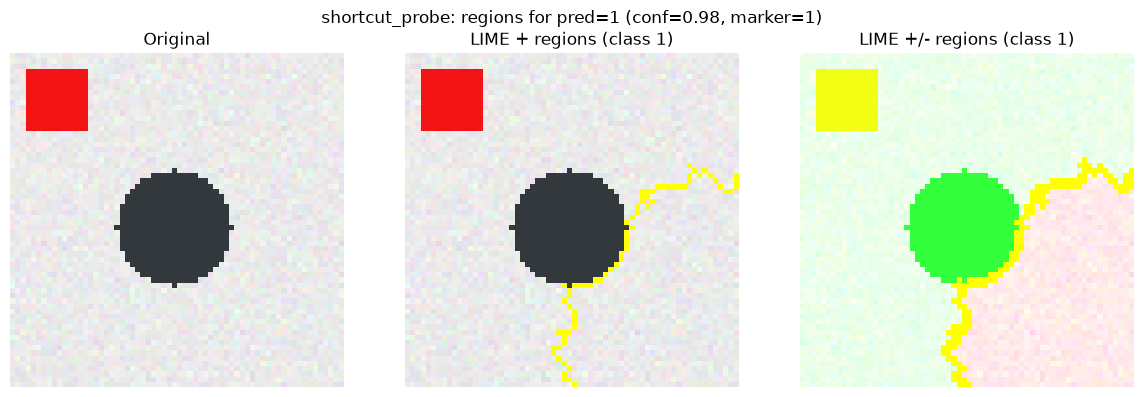

Trust reading: suspect


  0%|          | 0/800 [00:00<?, ?it/s]


=== IMAGE reference_square (idx=2) true=1 pred=1 conf=0.985 marker=1 ===
Local explanation strength (LIME local R^2): 0.685


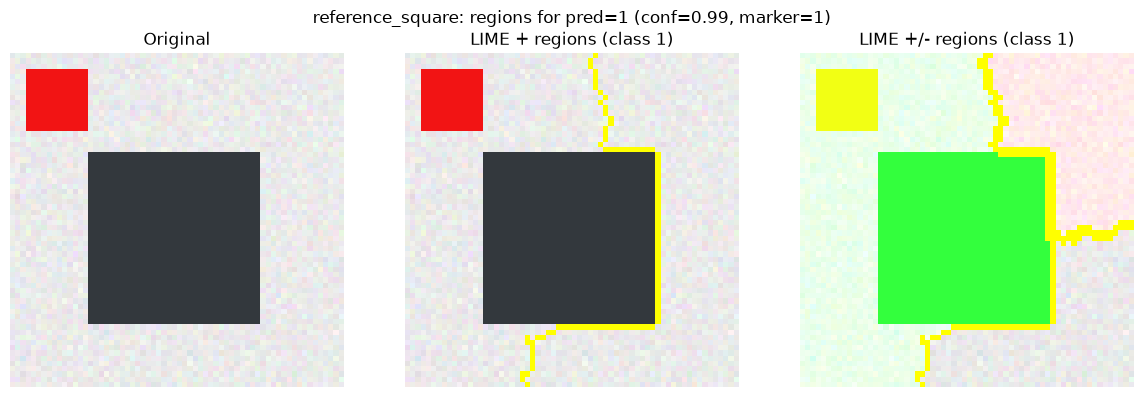

Trust reading: plausible_pending_review

--- Trust summary ---
Tabular high_case: conf=0.789, lime_score=0.748 -> LIME can support cautious trust if top features are domain-sensible.
Image shortcut_probe: conf=0.980, flag=suspect -> high confidence but LIME/marker evidence argues DO NOT trust.
Image reference_square: conf=0.985, flag=plausible_pending_review -> more compatible with intended shape+marker correlation; still not a full trust guarantee.


In [17]:
# Event 9: Estimate Trustworthiness — LIME local fidelity + explanation sanity
# Trust signals from LIME (partial):
#   1) model confidence
#   2) local surrogate fit (explanation.score / R^2)
#   3) whether credited evidence looks legitimate vs spurious
# LIME cannot fully establish trust (no calibration / OOD / global guarantees).

# Ensure helpers exist (re-run scratchpad if this fails)
assert "explain_tabular_lime" in dir() and "explain_image_lime" in dir(), (
    "Re-run the LIME helpers scratchpad cell, then re-run Event 9."
)


def trust_report_tabular(name, idx):
    row = X_test.iloc[idx]
    probs = predict_risk_proba(row.to_frame().T)[0]
    pred = int(probs.argmax())
    true = int(y_test.iloc[idx])
    conf = float(probs[pred])
    exp = explain_tabular_lime(row, num_features=6, num_samples=2000)
    score = float(exp.score)
    weights = exp.as_list(label=pred)
    print(f"\n=== TABULAR {name} (idx={idx}) true={true} pred={pred} conf={conf:.3f} ===")
    print(f"LIME local fidelity (R^2 / score): {score:.3f}")
    print("Top features for predicted class:")
    for feat, w in weights[:6]:
        print(f"  {feat}: {w:+.4f}")
    show_lime_tabular(exp, label=pred, title=f"{name}: LIME toward pred={pred}")
    # Heuristic: high conf + good local fit + debt/late-payment style features look more trustworthy
    # than unexplained confidence alone.
    return {"name": name, "conf": conf, "lime_score": score, "pred": pred, "true": true, "weights": weights}


def trust_report_image(name, idx):
    img = test_imgs[idx]
    probs = predict_image_proba(img[None, ...])[0]
    pred = int(probs.argmax())
    true = int(test_y[idx])
    conf = float(probs[pred])
    marker = int(test_marker[idx])
    exp = explain_image_lime(img, num_samples=800)
    raw_score = getattr(exp, "score", None)
    if isinstance(raw_score, dict):
        score = float(raw_score.get(pred, np.nan))
        score_note = "LIME local R^2"
    elif raw_score is not None:
        try:
            score = float(raw_score)
            score_note = "LIME local R^2"
        except (TypeError, ValueError):
            score = float("nan")
            score_note = "unavailable"
    else:
        local = dict(exp.local_exp[pred])
        score = float(np.mean(np.abs(list(local.values())))) if local else float("nan")
        score_note = "mean |segment weight| (fallback)"
    print(
        f"\n=== IMAGE {name} (idx={idx}) true={true} pred={pred} "
        f"conf={conf:.3f} marker={marker} ==="
    )
    print(f"Local explanation strength ({score_note}): {score:.3f}")
    show_lime_image_regions(
        img,
        exp,
        label=pred,
        num_features=5,
        title=f"{name}: regions for pred={pred} (conf={conf:.2f}, marker={marker})",
    )
    trust_flag = "suspect" if (marker == 1 and true == 0 and pred == 1) else "plausible_pending_review"
    print(f"Trust reading: {trust_flag}")
    return {
        "name": name,
        "conf": conf,
        "marker": marker,
        "pred": pred,
        "true": true,
        "trust_flag": trust_flag,
    }


# Compare a confident tabular case vs a suspicious image shortcut case
tab_case = trust_report_tabular("high_case", int(tabular_high_case))
img_case = trust_report_image("shortcut_probe", int(image_shortcut_case))
img_ref = trust_report_image("reference_square", int(image_reference_case))

print("\n--- Trust summary ---")
print(
    f"Tabular high_case: conf={tab_case['conf']:.3f}, lime_score={tab_case['lime_score']:.3f} "
    f"-> LIME can support cautious trust if top features are domain-sensible."
)
print(
    f"Image shortcut_probe: conf={img_case['conf']:.3f}, flag={img_case['trust_flag']} "
    f"-> high confidence but LIME/marker evidence argues DO NOT trust."
)
print(
    f"Image reference_square: conf={img_ref['conf']:.3f}, flag={img_ref['trust_flag']} "
    f"-> more compatible with intended shape+marker correlation; still not a full trust guarantee."
)

# Medal draft: Silver — LIME gives useful local fidelity + sanity checks for trust decisions,
# but cannot alone establish calibration, robustness, or true trustworthiness.


## Event 10: Reverse Engineer the Model

**Question:** What strategy has each model learned?

**Target:** Both target models

**Your task:** Synthesize evidence across events. A single output is usually not enough; explain what your method revealed and what remains unknown.

Before scoring, ask:

- What exactly did my method output?
- Does that output answer this event question?
- Could the output be misleading?
- What would a better-suited method show that mine does not?

TABULAR strategy sketch (mean LIME weight toward high-risk across probe cases):
  zip_proxy               mean_signed=-0.0662  |mean|=0.0662  n=16
  debt_ratio              mean_signed=+0.0316  |mean|=0.0316  n=16
  savings_k               mean_signed=+0.0091  |mean|=0.0091  n=16
  recent_late_payments    mean_signed=-0.0050  |mean|=0.0050  n=16
  support_tickets         mean_signed=-0.0049  |mean|=0.0049  n=16
  promo_seen              mean_signed=+0.0047  |mean|=0.0047  n=16
  loyalty_years           mean_signed=-0.0035  |mean|=0.0035  n=16
  income_k                mean_signed=+0.0035  |mean|=0.0035  n=16
  app_minutes             mean_signed=-0.0031  |mean|=0.0031  n=16
  age                     mean_signed=+0.0024  |mean|=0.0024  n=16


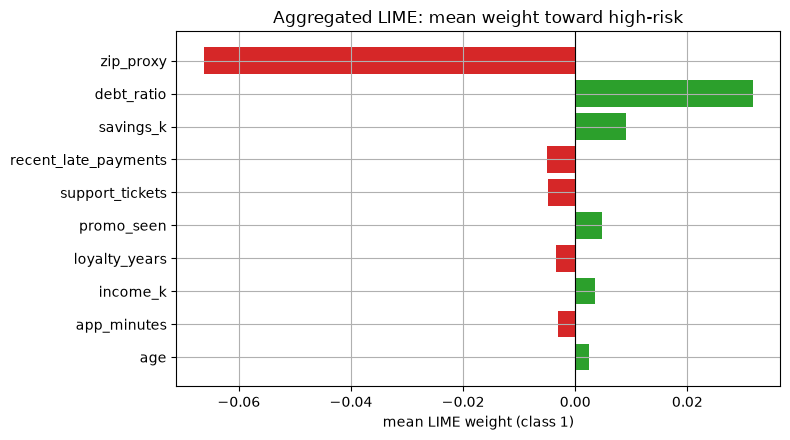


Tabular claim: the risk model appears to lean on debt_ratio / late payments / proxy-like fields (zip_proxy, promo_seen) more than benign usage features (app_minutes). Strategy ≈ credit-risk heuristics + possible zip/promo proxies.

IMAGE strategy probes:
  shortcut_probe (circle+marker): idx=5 true=0 pred=1 P(square)=0.980 marker=1


  0%|          | 0/800 [00:00<?, ?it/s]

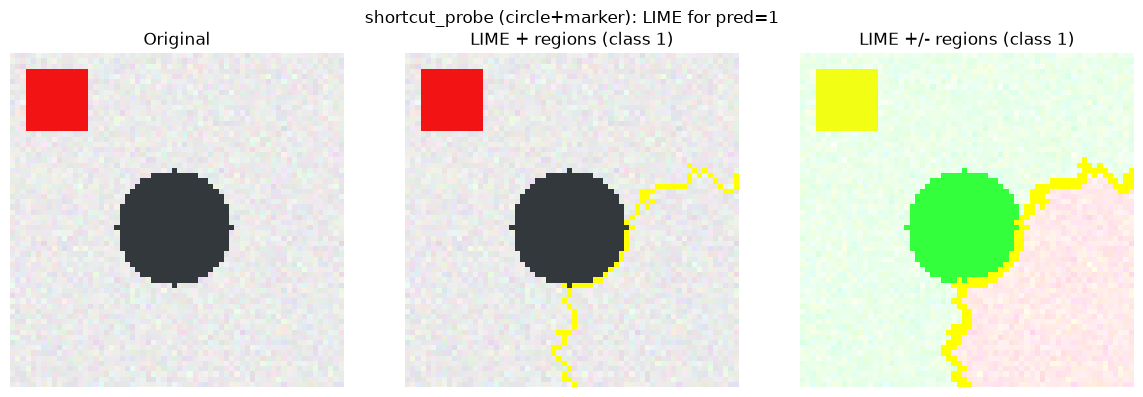

  reference_square (square+marker): idx=2 true=1 pred=1 P(square)=0.985 marker=1


  0%|          | 0/800 [00:00<?, ?it/s]

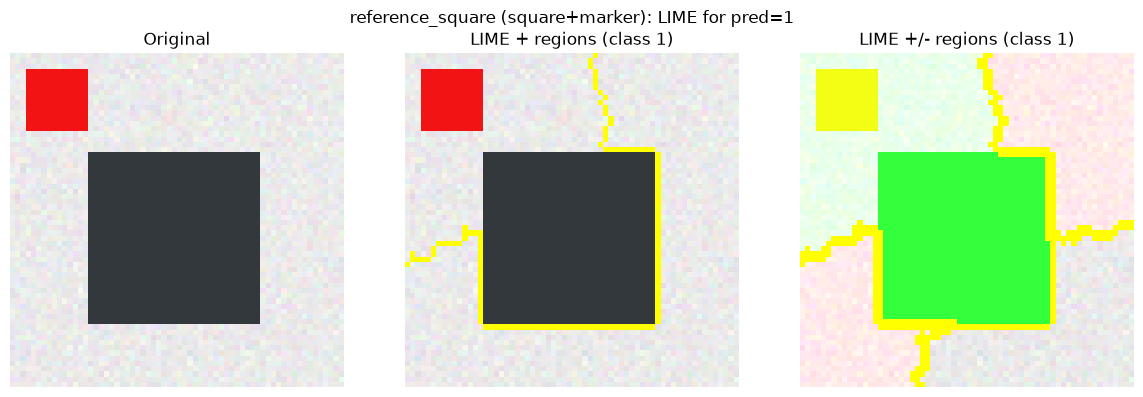

  contrast_square (square, no marker): idx=4 true=1 pred=0 P(square)=0.066 marker=0


  0%|          | 0/800 [00:00<?, ?it/s]

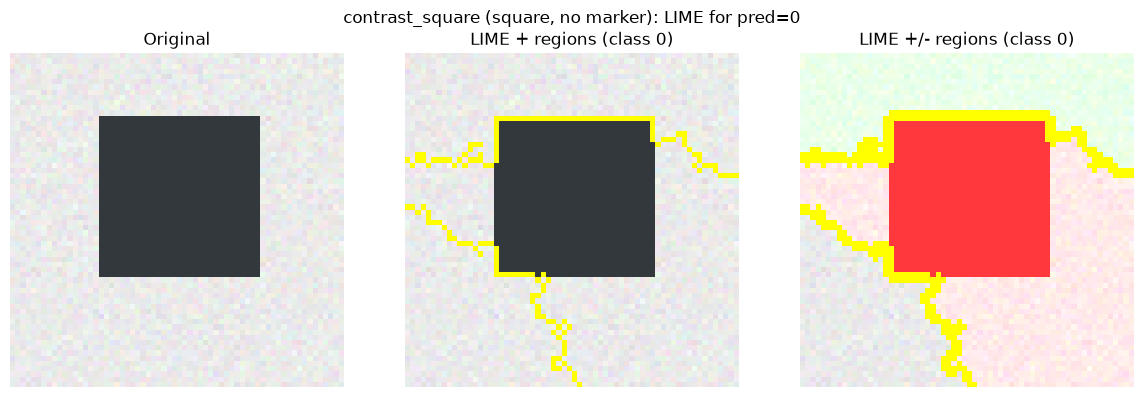


Image claim: predictions track the red corner marker more than shape. shortcut_probe (circle+marker) → square; contrast_square (square, no marker) often drops P(square). Strategy ≈ marker shortcut (with possible weak shape signal).

Method limit: aggregated LIME sketches strategy from local surrogates; it is not a true global attribution (SHAP/PDP/ALE) or causal proof of shortcuts.


In [18]:
# Event 10: Reverse-engineer strategies by synthesizing many local LIME explanations.
# LIME is local; aggregating locals sketches a global strategy (approximate).

assert "explain_tabular_lime" in dir() and "explain_image_lime" in dir(), (
    "Re-run the LIME helpers scratchpad cell, then re-run Event 10."
)

# ---------- Tabular strategy: mean |LIME weight| across several cases ----------
tabular_probe_idxs = sorted(
    {
        int(tabular_low_case),
        int(tabular_high_case),
        int(tabular_local_case),
        int(tabular_failure_case),
        *map(int, np.linspace(0, len(X_test) - 1, 12)),
    }
)

# Collect signed weights toward high-risk (class 1), keyed by raw feature name when possible
from collections import defaultdict

feature_weight_sums = defaultdict(float)
feature_weight_counts = defaultdict(int)

for idx in tabular_probe_idxs:
    row = X_test.iloc[idx]
    exp = explain_tabular_lime(row, num_features=len(feature_names), num_samples=1500)
    for feat_desc, w in exp.as_list(label=1):
        # map discretized descriptor back to base feature name
        base = next((f for f in feature_names if f in feat_desc), feat_desc)
        feature_weight_sums[base] += float(w)
        feature_weight_counts[base] += 1

mean_signed = {
    f: feature_weight_sums[f] / max(feature_weight_counts[f], 1) for f in feature_weight_sums
}
mean_abs_rank = sorted(
    ((f, abs(mean_signed[f]), mean_signed[f]) for f in mean_signed),
    key=lambda t: -t[1],
)

print("TABULAR strategy sketch (mean LIME weight toward high-risk across probe cases):")
for f, mag, signed in mean_abs_rank:
    print(f"  {f:22s}  mean_signed={signed:+.4f}  |mean|={mag:.4f}  n={feature_weight_counts[f]}")

rank_names = [f for f, _, _ in mean_abs_rank][::-1]
rank_vals = [signed for _, _, signed in mean_abs_rank][::-1]
colors = ["#2ca02c" if v > 0 else "#d62728" for v in rank_vals]
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(rank_names, rank_vals, color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_title("Aggregated LIME: mean weight toward high-risk")
ax.set_xlabel("mean LIME weight (class 1)")
plt.tight_layout()
plt.show()

print(
    "\nTabular claim: the risk model appears to lean on debt_ratio / late payments / "
    "proxy-like fields (zip_proxy, promo_seen) more than benign usage features "
    "(app_minutes). Strategy ≈ credit-risk heuristics + possible zip/promo proxies."
)

# ---------- Image strategy: contrast cases that separate shape vs marker ----------
image_strategy_cases = [
    ("shortcut_probe (circle+marker)", int(image_shortcut_case)),
    ("reference_square (square+marker)", int(image_reference_case)),
    ("contrast_square (square, no marker)", int(image_contrast_case)),
]

print("\nIMAGE strategy probes:")
for name, idx in image_strategy_cases:
    img = test_imgs[idx]
    probs = predict_image_proba(img[None, ...])[0]
    pred = int(probs.argmax())
    print(
        f"  {name}: idx={idx} true={test_y[idx]} pred={pred} "
        f"P(square)={probs[1]:.3f} marker={test_marker[idx]}"
    )
    exp = explain_image_lime(img, num_samples=800)
    show_lime_image_regions(
        img,
        exp,
        label=pred,
        num_features=5,
        title=f"{name}: LIME for pred={pred}",
    )

print(
    "\nImage claim: predictions track the red corner marker more than shape. "
    "shortcut_probe (circle+marker) → square; contrast_square (square, no marker) "
    "often drops P(square). Strategy ≈ marker shortcut (with possible weak shape signal)."
)

print(
    "\nMethod limit: aggregated LIME sketches strategy from local surrogates; "
    "it is not a true global attribution (SHAP/PDP/ALE) or causal proof of shortcuts."
)


**Event 10 notes (LIME)**

- **Output:** Aggregated tabular LIME weights across probe cases + side-by-side image LIME maps for shortcut / reference / contrast cases.
- **Claim:** Tabular model ≈ debt/late-payment risk heuristics (+ possible zip/promo proxies). Image model ≈ red-marker shortcut more than shape.
- **Evidence quality:** Partial global picture built from many locals — useful synthesis, not a true global method.
- **Medal:** Silver

# Final Model Profile

Team synthesis across Events 1–10 with **LIME**.

**Tabular model strategy:**  
High-risk predictions are driven mainly by debt / late-payment style features (`debt_ratio`, `recent_late_payments`), with strong local influence from proxy-like fields (`zip_proxy`, sometimes `promo_seen`). Raising `debt_ratio` raises mean P(high risk) and LIME debt weights (Event 4). Pairwise contrast of low vs high cases (Event 5) points to the same drivers. LIME did **not** detect age×debt interactions (Event 6 DNF) because the default local surrogate is additive.

**Image model strategy:**  
The classifier relies heavily on the red corner marker shortcut more than shape: circle+marker is predicted square at high confidence, while square without marker drops P(square) sharply (Events 3, 7, 8, 10). LIME region maps credit the marker area for those predictions.

**Method decathlon profile:**  
- **Strong (Gold):** local tabular explanation (2), shortcut diagnosis (3), image localization (7), failure attribution (8).  
- **Partial (Silver):** approximate global importance (1), global feature effect via stacked locals (4), contrastive cases (5), trust flags (9), strategy synthesis (10).  
- **Mismatch (DNF):** feature interactions (6) — need SHAP interactions / two-way PDP/ALE.

**Open questions:**  
Compare with SHAP (global + local consistency), Grad-CAM/Score-CAM (dense image localization), and PDP/ALE (global effects / interactions).
